# TPI 1: Adquisición y Análisis Lingüístico de Medios

**Modalidad:** Trabajo Práctico Individual (calificación numérica de 0 a 10).

**Fecha de entrega y exposición:** Jueves 16 de abril. Se realizará de manera expositiva en remoto frente a todo el grupo de estudiantes (aproximadamente 10 minutos por presentación) para que entre quienes participan veamos posibles soluciones.

**Duración estimada de codificación:** 2 horas

**Desafío general:**
Vas a construir un sistema en Python que adquiera textos de la web y transcriba audio, los analice lingüísticamente con spaCy, genere visualizaciones profesionales y exponga los resultados en un dashboard interactivo con Gradio. Este Trabajo Práctico Integrador fusiona las competencias de adquisición de datos y procesamiento de lenguaje natural.

**Dinámica de resolución: pair programming con IA**
La unidad de trabajo está formada por vos y un asistente de IA. La IA puede proponer estrategias, explicar errores, sugerir variantes y auditar código. No reemplaza tu pensamiento ni tu criterio. Toda decisión final, toda justificación y toda versión entregada tienen que estar bajo tu responsabilidad.

---

### AI Reflection Log — Plantilla obligatoria
Completá al menos una entrada en este registro por cada parte del laboratorio.

| Parte | Objetivo de la consulta | Prompt o pedido a la IA | Qué responidó (resumen) | Qué conservaste y por qué | Qué descartaste y por qué | Qué aprendiste |
|---|---|---|---|---|---|---|
| **Parte 1** | Generar JSON de Ámbito con Playwright y scrapear notas de otros medios |"Escribime un script de Playwright para extraer artículos de búsqueda de Ámbito sobre Peter Thiel" | Propuso selectores CSS genéricos que no funcionaron; tras inspeccionar el DOM detectamos que Ámbito usa Google CSE con clase `gsc-webResult`  |Conservamos la estructura con `data-ctorig` para obtener URLs limpias  |Descartamos los selectores genéricos h2/h3 que capturaban noticias irrelevantes | El DOM real siempre hay que inspeccionarlo; la IA no puede verlo  |
| **Parte 2** |Entender criterios PER/ORG/LOC de spaCy y detectar errores del modelo  | "¿Qué criterios usa spaCy para clasificar PER, ORG y LOC?"  |Explicó correctamente la teoría pero el modelo real dispersó "Palantir" en tres categorías distintas  |Conservamos la lógica de extracción y agregamos post-procesamiento con diccionario de correcciones y normalización  |Descartamos confiar ciegamente en el output del modelo sin auditoría humana |Los modelos NLP fallan con nombres propios poco frecuentes en español  |
| **Parte 3** |Elegir entre WordCloud y Barplot para toma de decisiones  | "¿Conviene WordCloud o Barplot para un informe de toma de decisiones?" |Recomendó Barplot por el principio Data-Ink Ratio de Tufte |Conservamos Barplot y Lollipop Chart; agregamos subplots separados por tipo en Plotly |Descartamos WordCloud como visualización principal  |La precisión visual importa más que la estética en contextos analíticos |
| **Parte 4** |Decidir qué exportar en CSV vs JSON  | "¿Qué información va en CSV y qué en JSON jerárquico?" |Explicó que CSV es para datos tabulares crudos y JSON para estructuras jerárquicas  |Conservamos ambos formatos con propósitos distintos: CSV para el corpus, JSON para el análisis |Descartamos exportar todo en un solo formato  | CSV y JSON no son intercambiables; responden a necesidades distintas de los usuarios |
| **Parte 5** |Elegir layout del dashboard y resolver conflicto de matplotlib con Gradio | "Proponé tres layouts para el dashboard" |Propuso columna vertical, acordeón y pestañas |Conservamos pestañas (gr.Tab) por ser el patrón más familiar para dashboards analíticos |Descartamos acordeón (oculta contexto) y columna vertical (demasiado scroll) |matplotlib.use('Agg') debe ir dentro de las funciones, no de forma global |

In [ ]:
# PASO 0: Instalación de las librerías necesarias
# Ejecutá esta celda una sola vez.
#!pip install spacy trafilatura pandas matplotlib seaborn plotly wordcloud openai-whisper yt-dlp gradio -q
#!python -m spacy download es_core_news_lg -q

# La primera consulta que hice al asistente es que me diga todo lo que voy a necesitar en una sola celda:
# PASO 0: Instalación de las librerías necesarias
# Ejecutá esta celda una sola vez.
# Playwright: necesario para generar el JSON de Ámbito con el navegador real
# Librerías adicionales que usaremos

In [ ]:

!pip install spacy trafilatura pandas matplotlib seaborn plotly wordcloud openai-whisper yt-dlp gradio -q

!pip install playwright -q

!pip install requests beautifulsoup4 -q  
!pip install nltk -q               

!python -m spacy download es_core_news_lg -q

print("✓ Todo instalado correctamente.")

El asistente recomienda hacer correr el playright en una celda aparte

In [2]:
!playwright install chromium


In [1]:
import spacy
import pandas as pd
import trafilatura
import whisper
import json
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from collections import Counter
from wordcloud import WordCloud
import os
import re
import random
import requests
from bs4 import BeautifulSoup
from playwright.sync_api import sync_playwright
import yt_dlp
import nltk

print("Librerías importadas correctamente.")

c:\PLN - Repositorios\estigarribia-carlos-pln-1c-2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías importadas correctamente.


## Parte 1: Adquisición Multimodal del Corpus

**Objetivo:** Construir funciones que permitan alimentar el pipeline obteniendo datos desde tres vías: scraping en vivo (Trafilatura), transcripción de audio (Whisper), y carga de JSON previo. Luego, unificarlas en un único DataFrame.

> [!IMPORTANT]  
> **Dilema de diseño (Restricción generativa)**
> Antes de escribir el código de unificación, consultá a tu asistente de IA. Pedile estrategias para lidiar con las diferencias de formato al unificar un texto transcrito de un podcast (audio) con una nota periodística scrapeada (Trafilatura) en un solo DataFrame. 
> Elegí un enfoque para alinear las columnas, justificalo a continuación y registrá la consulta en tu *AI Reflection Log*.

**Escribí tu justificación acá:**
(*Tu respuesta...*)

# CELDA 0a: Generación del corpus JSON desde Ámbito Financiero
# Usamos Playwright (igual que en el Lab 4 con La Nación) para navegar la página de búsqueda de Ámbito y extraer los artículos sobre Peter Thiel.
# Necesitamos %%writefile porque Playwright no puede correr dentro del loop de eventos de Jupyter (mismo motivo que en el Lab 4).
AI Reflection Log: esta celda no puede ir en la celda del json porque va dar error (aunque esté comentada con "#")

In [2]:
%%writefile ambito_peter_thiel.py
import json
from playwright.sync_api import sync_playwright

URL = "https://www.ambito.com/contenidos/resultado.html?search=peter+thiel"

def run():
    with sync_playwright() as p:
        browser = p.chromium.launch(headless=False)
        context = browser.new_context(
            user_agent="Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36"
        )
        page = context.new_page()

        print("Navegando a Ámbito - búsqueda de Peter Thiel...")
        page.goto(URL, wait_until="domcontentloaded")
        page.wait_for_timeout(5000)

        # Cerramos modal de cookies si aparece
        try:
            boton = page.wait_for_selector('button:has-text("Aceptar")', timeout=3000)
            if boton:
                boton.click()
                print("Modal cerrado.")
        except:
            pass

        # Esperamos que cargue el motor de búsqueda de Google (gsc)
        print("Esperando resultados del buscador...")
        try:
            page.wait_for_selector("div.gsc-webResult.gsc-result", timeout=10000)
        except:
            print("Timeout esperando resultados gsc. Continuamos...")
        page.wait_for_timeout(2000)

        # Extraemos usando los selectores correctos del motor Google CSE
        print("Extrayendo artículos...")
        articulos = page.evaluate("""
            () => {
                const resultados = [];
                const items = document.querySelectorAll('div.gsc-webResult.gsc-result');

                for (const item of items) {
                    const enlace = item.querySelector('a.gs-title');
                    if (!enlace) continue;

                    const titulo = enlace.innerText.trim();
                    
                    // El href real está en data-ctorig (URL limpia sin redirección de Google)
                    const url = enlace.getAttribute('data-ctorig') || enlace.href;

                    if (titulo.length > 5) {
                        resultados.push({
                            titulo: titulo,
                            seccion: "Búsqueda Ámbito - Peter Thiel",
                            url: url
                        });
                    }
                }
                return resultados;
            }
        """)

        print(f"Se encontraron {len(articulos)} artículos.")
        browser.close()

        with open("ambito_peter_thiel.json", "w", encoding="utf-8") as f:
            json.dump(articulos, f, indent=4, ensure_ascii=False)
        print("Archivo 'ambito_peter_thiel.json' guardado correctamente.")

        print("\nPreview de los primeros 5 artículos:")
        print("-" * 50)
        for nota in articulos[:5]:
            print(f"[{nota['seccion'].upper()}] -> {nota['titulo']}")
            print(f"  URL: {nota['url']}")

if __name__ == "__main__":
    run()

Writing ambito_peter_thiel.py


In [3]:
# CELDA 0b: Ejecutamos el script externo con !python (mismo patrón que Lab 4).
# Al correr esta celda se abrirá una ventana de Chromium visible.
# Al finalizar, quedará guardado 'ambito_peter_thiel.json' en el directorio de trabajo.

!python ambito_peter_thiel.py

Navegando a Ámbito - búsqueda de Peter Thiel...
Modal cerrado.
Esperando resultados del buscador...
Extrayendo artículos...
Se encontraron 10 artículos.
Archivo 'ambito_peter_thiel.json' guardado correctamente.

Preview de los primeros 5 artículos:
--------------------------------------------------
[BÚSQUEDA ÁMBITO - PETER THIEL] -> El magnate tech Peter Thiel compró la casa más cara de Buenos ...
  URL: https://www.ambito.com/real-estate/el-magnate-tech-peter-thiel-compro-la-casa-mas-cara-buenos-aires-su-visita-la-argentina-n6270040
[BÚSQUEDA ÁMBITO - PETER THIEL] -> Quién es Peter Thiel, el magnate tecnológico de Sillicon Valley que ...
  URL: https://www.ambito.com/negocios/quien-es-peter-thiel-el-magnate-tecnologico-sillicon-valley-que-llego-perfil-la-argentina-n6269163
[BÚSQUEDA ÁMBITO - PETER THIEL] -> Elisa Carrió cuestionó la visita de Peter Thiel y advirtió sobre su ...
  URL: https://www.ambito.com/politica/elisa-carrio-cuestiono-la-visita-peter-thiel-y-advirtio-su-influencia

In [4]:
# Limpieza del script temporal generado con %%writefile
import os
if os.path.exists("ambito_peter_thiel.py"):
    os.remove("ambito_peter_thiel.py")
    print("Script temporal eliminado.")

Script temporal eliminado.


In [5]:
# Verificación del JSON generado
import json

with open("ambito_peter_thiel.json", "r", encoding="utf-8") as f:
    datos = json.load(f)

print(f"Total de artículos sobre Peter Thiel en Ámbito: {len(datos)}")
print("-" * 50)
for i, nota in enumerate(datos, 1):
    print(f"{i}. {nota['titulo']}")
    print(f"   {nota['url']}")

Total de artículos sobre Peter Thiel en Ámbito: 10
--------------------------------------------------
1. El magnate tech Peter Thiel compró la casa más cara de Buenos ...
   https://www.ambito.com/real-estate/el-magnate-tech-peter-thiel-compro-la-casa-mas-cara-buenos-aires-su-visita-la-argentina-n6270040
2. Quién es Peter Thiel, el magnate tecnológico de Sillicon Valley que ...
   https://www.ambito.com/negocios/quien-es-peter-thiel-el-magnate-tecnologico-sillicon-valley-que-llego-perfil-la-argentina-n6269163
3. Elisa Carrió cuestionó la visita de Peter Thiel y advirtió sobre su ...
   https://www.ambito.com/politica/elisa-carrio-cuestiono-la-visita-peter-thiel-y-advirtio-su-influencia-la-argentina-n6270402
4. Los 22 puntos del manifiesto de Palantir: los ejes más oscuros de la ...
   https://www.ambito.com/negocios/los-22-puntos-del-manifiesto-palantir-los-ejes-mas-oscuros-la-empresa-del-magnate-que-se-reunio-milei-n6270497
5. Peter Thiel, el inversor que apostó por el futuro - Ámbito

In [6]:
# Filtramos artículos no relevantes al tema Peter Thiel / su visita a Argentina
urls_a_excluir = [
    "https://www.ambito.com/tecnologia-old",
    "https://www.ambito.com/tecnologia/como-usar-el-efecto-flash-instagram-viral-todas-las-redes-n6269502"
]

datos_limpios = [art for art in datos if art["url"] not in urls_a_excluir]

# Guardamos el JSON limpio
with open("ambito_peter_thiel.json", "w", encoding="utf-8") as f:
    json.dump(datos_limpios, f, indent=4, ensure_ascii=False)

print(f"JSON limpio guardado: {len(datos_limpios)} artículos relevantes.")
print("-" * 50)
for i, nota in enumerate(datos_limpios, 1):
    print(f"{i}. {nota['titulo']}")

JSON limpio guardado: 9 artículos relevantes.
--------------------------------------------------
1. El magnate tech Peter Thiel compró la casa más cara de Buenos ...
2. Quién es Peter Thiel, el magnate tecnológico de Sillicon Valley que ...
3. Elisa Carrió cuestionó la visita de Peter Thiel y advirtió sobre su ...
4. Los 22 puntos del manifiesto de Palantir: los ejes más oscuros de la ...
5. Peter Thiel, el inversor que apostó por el futuro - Ámbito Financiero
6. De cuánto es la fortuna de Peter Thiel, el multimillonario que está ...
7. Javier Milei recibió al magnate de Sillicon Valley Peter Thiel
8. Trabajó con Elon Musk para crear PayPal y hoy es multimillonario
9. La Fundación Libertad volverá a reunir a Javier Milei y Mauricio ...


In [7]:
# 1.1 Scraping en vivo
def extraer_noticias_web(urls):
    """Extrae el texto completo de una lista de URLs usando Trafilatura.
    Retorna una lista de diccionarios con título, texto y origen."""
    noticias = []
    for url in urls:
        try:
            descargado = trafilatura.fetch_url(url)
            if descargado:
                texto = trafilatura.extract(
                    descargado,
                    include_comments=False,
                    include_images=False
                )
                if texto:
                    noticias.append({
                        "titulo_o_fuente": url.split("/")[-1],
                        "texto": texto,
                        "origen": "web_trafilatura",
                        "url": url
                    })
                    print(f"✓ Extraído: {url.split('/')[-1][:60]}")
                else:
                    print(f"✗ Sin texto: {url}")
            else:
                print(f"✗ Sin descarga: {url}")
        except Exception as e:
            print(f"✗ Error en {url}: {e}")
    return noticias


# URLs a scrapear: Ámbito + medios de distintas líneas editoriales
urls_peter_thiel = [
    # Ámbito Financiero
    "https://www.ambito.com/negocios/quien-es-peter-thiel-el-magnate-tecnologico-sillicon-valley-que-llego-perfil-la-argentina-n6269163",
    "https://www.ambito.com/politica/elisa-carrio-cuestiono-la-visita-peter-thiel-y-advirtio-su-influencia-la-argentina-n6270402",
    "https://www.ambito.com/politica/javier-milei-se-reunira-peter-thiel-fundador-paypal-y-palantir-n6269616",
    # Perfil
    "https://www.perfil.com/noticias/nea/peter-thiel-en-argentina-negocios-poder-y-senales-al-modelo-milei.phtml",
    # El Destape
    "https://www.eldestapeweb.com/politica/thiel-en-argentina-que-piensa-y-que-planea-el-dueno-de-palantir-que-se-reunira-con-milei-2026423103234",
    # Tiempo Argentino
    "https://www.tiempoar.com.ar/ta_article/quien-es-peter-thiel-el-magnate-tecnocrata-que-se-reune-con-milei-en-casa-rosada-y-no-cree-en-la-democracia/",
]

# Ejecutamos la extracción
print("Iniciando scraping con Trafilatura...")
print("=" * 50)
datos_web = extraer_noticias_web(urls_peter_thiel)
print("=" * 50)
print(f"\nTotal de artículos extraídos exitosamente: {len(datos_web)}")
print(f"Primeros 300 caracteres del primer artículo:")
print("-" * 50)
if datos_web:
    print(datos_web[0]["texto"][:300])

Iniciando scraping con Trafilatura...
✓ Extraído: quien-es-peter-thiel-el-magnate-tecnologico-sillicon-valley-
✓ Extraído: elisa-carrio-cuestiono-la-visita-peter-thiel-y-advirtio-su-i
✓ Extraído: javier-milei-se-reunira-peter-thiel-fundador-paypal-y-palant
✓ Extraído: peter-thiel-en-argentina-negocios-poder-y-senales-al-modelo-
✓ Extraído: thiel-en-argentina-que-piensa-y-que-planea-el-dueno-de-palan
✓ Extraído: 

Total de artículos extraídos exitosamente: 6
Primeros 300 caracteres del primer artículo:
--------------------------------------------------
El magnate tecnológico Peter Thiel, una de las figuras más influyentes y controvertidas de Silicon Valley, se encuentra en Buenos Aires desde hace más de una semana, en una visita marcada por el hermetismo y un bajo perfil inusual incluso para los estándares del mundo corporativo. La única actividad


In [8]:
print(f"Artículos extraídos con Trafilatura: {len(datos_web)}")
for i, art in enumerate(datos_web, 1):
    print(f"{i}. [{art['origen']}] {art['titulo_o_fuente'][:60]}")

Artículos extraídos con Trafilatura: 6
1. [web_trafilatura] quien-es-peter-thiel-el-magnate-tecnologico-sillicon-valley-
2. [web_trafilatura] elisa-carrio-cuestiono-la-visita-peter-thiel-y-advirtio-su-i
3. [web_trafilatura] javier-milei-se-reunira-peter-thiel-fundador-paypal-y-palant
4. [web_trafilatura] peter-thiel-en-argentina-negocios-poder-y-senales-al-modelo-
5. [web_trafilatura] thiel-en-argentina-que-piensa-y-que-planea-el-dueno-de-palan
6. [web_trafilatura] 


In [9]:
# Verificamos que el artículo 6 tiene texto
print(f"Título/fuente: '{datos_web[5]['titulo_o_fuente']}'")
print(f"URL: {datos_web[5]['url']}")
print(f"Caracteres de texto: {len(datos_web[5]['texto'])}")
print(f"\nPrimeros 200 caracteres:")
print(datos_web[5]['texto'][:200])

Título/fuente: ''
URL: https://www.tiempoar.com.ar/ta_article/quien-es-peter-thiel-el-magnate-tecnocrata-que-se-reune-con-milei-en-casa-rosada-y-no-cree-en-la-democracia/
Caracteres de texto: 9843

Primeros 200 caracteres:
Peter Thiel está en Argentina. Para quiénes conocen al personaje, la noticia cayó como una bomba. Con 29.300 millones de dólares, Thiel está en el puesto 87 de los más ricos del mundo según Forbes. Fo


In [10]:
# Corregimos el título vacío del artículo 6 (Tiempo Argentino)
datos_web[5]['titulo_o_fuente'] = "quien-es-peter-thiel-magnate-tecnocrata-tiempo-argentino"
print(f"✓ Título corregido: {datos_web[5]['titulo_o_fuente']}")

✓ Título corregido: quien-es-peter-thiel-magnate-tecnocrata-tiempo-argentino


In [11]:
print(f"\nResumen final de datos_web:")
print("-" * 50)
for i, art in enumerate(datos_web, 1):
    print(f"{i}. {art['titulo_o_fuente'][:60]} ({len(art['texto'])} caracteres)")


Resumen final de datos_web:
--------------------------------------------------
1. quien-es-peter-thiel-el-magnate-tecnologico-sillicon-valley- (8082 caracteres)
2. elisa-carrio-cuestiono-la-visita-peter-thiel-y-advirtio-su-i (3536 caracteres)
3. javier-milei-se-reunira-peter-thiel-fundador-paypal-y-palant (5289 caracteres)
4. peter-thiel-en-argentina-negocios-poder-y-senales-al-modelo- (3115 caracteres)
5. thiel-en-argentina-que-piensa-y-que-planea-el-dueno-de-palan (22197 caracteres)
6. quien-es-peter-thiel-magnate-tecnocrata-tiempo-argentino (9843 caracteres)


## Parte 1.2: Transcripción de audio con Whisper
Descargamos el audio del video de Claudio Fantini sobre Peter Thiel en Argentina
usando yt-dlp, y lo transcribimos localmente con Whisper modelo 'small'.
Seguimos el patrón del Lab 7: %%writefile + !python para evitar conflictos con asyncio.

In [12]:
%%writefile transcribir_fantini.py
import whisper
import yt_dlp
import os

# URL específica del video 
URL_VIDEO = "https://www.youtube.com/watch?v=pXck4dbK-I8"
AUDIO_DIR = "audios"
OUTPUT_DIR = "transcripciones"

os.makedirs(AUDIO_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

ydl_opts = {
    'format': 'bestaudio/best',
    'noplaylist': True,
    'postprocessors': [{
        'key': 'FFmpegExtractAudio',
        'preferredcodec': 'mp3',
        'preferredquality': '192',
    }],
    'outtmpl': f'{AUDIO_DIR}/audio_input.%(ext)s', 
    'ffmpeg_location': r'C:\ProgramData\chocolatey\bin',
}

try:
    print("--- PASO 1: Descargando audio ---")
    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        ydl.download([URL_VIDEO])
    
    audio_path = os.path.join(AUDIO_DIR, "audio_input.mp3")

    print(f"\n--- PASO 2: Transcribiendo con Whisper ---")
    modelo = whisper.load_model("small")
    resultado = modelo.transcribe(audio_path, language="es", fp16=False)

    nombre_base = "fantini-peter-thiel-argentina"
    with open(f"{OUTPUT_DIR}/{nombre_base}.txt", "w", encoding="utf-8") as f:
        f.write(resultado["text"].strip())

    print(f"\n✅ ÉXITO: Archivo generado en {OUTPUT_DIR}/{nombre_base}.txt")

except Exception as e:
    print(f"\n❌ ERROR: {e}")


Overwriting transcribir_fantini.py


In [13]:
# Ejecutamos el script de descarga y transcripción
# La transcripción puede tardar entre 3 y 10 minutos dependiendo del largo del video
!python transcribir_fantini.py

--- PASO 1: Descargando audio ---
[youtube] Extracting URL: https://www.youtube.com/watch?v=pXck4dbK-I8
[youtube] pXck4dbK-I8: Downloading webpage
[youtube] pXck4dbK-I8: Downloading android vr player API JSON
[info] pXck4dbK-I8: Downloading 1 format(s): 251
[download] Destination: audios\audio_input.webm

[download]   0.0% of   20.24MiB at  203.65KiB/s ETA 01:41
[download]   0.0% of   20.24MiB at  610.94KiB/s ETA 00:33
[download]   0.0% of   20.24MiB at    1.39MiB/s ETA 00:14
[download]   0.1% of   20.24MiB at    2.16MiB/s ETA 00:09
[download]   0.1% of   20.24MiB at    3.86MiB/s ETA 00:05
[download]   0.3% of   20.24MiB at    3.26MiB/s ETA 00:06
[download]   0.6% of   20.24MiB at    1.00MiB/s ETA 00:20
[download]   1.2% of   20.24MiB at  968.07KiB/s ETA 00:21
[download]   2.5% of   20.24MiB at    1.41MiB/s ETA 00:14
[download]   4.9% of   20.24MiB at    1.52MiB/s ETA 00:12
[download]   9.9% of   20.24MiB at  951.75KiB/s ETA 00:19
[download]  13.2% of   20.24MiB at    1.04MiB/s ETA 00:

In [ ]:
!ffmpeg -version


In [14]:
# 1.2 Transcripción de Audio
def transcribir_audio_youtube(url_video):
    """Descarga el audio de un video de YouTube y lo transcribe usando Whisper"""
    import subprocess
    import yt_dlp
    
    # PASO 2: Utilizá yt-dlp para descargar el audio.
    # Luego, cargá el modelo 'small' o 'base' de whisper y transcribí el archivo generado.
    # Tip: podés reutilizar la lógica del Laboratorio 007.
    
    return []

In [15]:
# Verificamos la transcripción generada por Whisper
with open("transcripciones/fantini-peter-thiel-argentina.txt", "r", encoding="utf-8") as f:
    texto_transcripto = f.read()

print(f"Total de caracteres transcriptos: {len(texto_transcripto)}")
print(f"Total de palabras aproximadas: {len(texto_transcripto.split())}")
print(f"\nPrimeros 400 caracteres:")
print("-" * 50)
print(texto_transcripto[:400])

Total de caracteres transcriptos: 11136
Total de palabras aproximadas: 1908

Primeros 400 caracteres:
--------------------------------------------------
Curiosamente, uno de los nombres que más retumbó en la Argentina de estos días es un nombre desconocido para el 90% o más de los argentinos. Peter Thiel. Peter Thiel fue recibido por segunda vez por el presidente Javier Milay en la Casa Rosada, se anunció que compró una mansión en una zona muy aristocrática de Buenos Aires, barrio Parque, y que va a traer inversiones seguramente parte de su empres


In [16]:
# 1.2 Transcripción de Audio
def transcribir_audio_youtube(url_video):
    """Descarga el audio de un video de YouTube y lo transcribe usando Whisper.
    Retorna una lista con un diccionario con título, texto y origen.
    Nota: el script de descarga y transcripción se ejecuta externamente
    con %%writefile + !python para evitar conflictos con asyncio en Jupyter."""
    datos_audio = []
    try:
        ruta_txt = "transcripciones/fantini-peter-thiel-argentina.txt"
        if os.path.exists(ruta_txt):
            with open(ruta_txt, "r", encoding="utf-8") as f:
                texto = f.read()
            datos_audio.append({
                "titulo_o_fuente": "fantini-peter-thiel-argentina",
                "texto": texto,
                "origen": "audio_whisper",
                "url": url_video
            })
            print(f"✓ Transcripción cargada: {len(texto)} caracteres")
        else:
            print("✗ No se encontró el archivo de transcripción.")
    except Exception as e:
        print(f"✗ Error al cargar transcripción: {e}")
    return datos_audio


# Cargamos los datos de audio
datos_audio = transcribir_audio_youtube("https://www.youtube.com/watch?v=pXck4dbK-I8")
print(f"Total registros de audio: {len(datos_audio)}")

✓ Transcripción cargada: 11136 caracteres
Total registros de audio: 1


In [17]:
# 1.3 Carga de JSON local
def cargar_json_previo(ruta_json):
    """Carga el corpus pre-extraído en formato JSON generado con Playwright.
    Retorna una lista de diccionarios con título, texto y origen."""
    datos = []
    try:
        with open(ruta_json, "r", encoding="utf-8") as f:
            articulos = json.load(f)
        for art in articulos:
            datos.append({
                "titulo_o_fuente": art.get("titulo", "sin-titulo"),
                "texto": art.get("titulo", ""),  # el JSON de Ámbito tiene títulos, no texto completo
                "origen": "json_playwright",
                "url": art.get("url", "")
            })
        print(f"✓ JSON cargado: {len(datos)} artículos desde '{ruta_json}'")
    except Exception as e:
        print(f"✗ Error al cargar JSON: {e}")
    return datos


# Cargamos el JSON generado con Playwright en la celda 0b
datos_json = cargar_json_previo("ambito_peter_thiel.json")

print(f"\nResumen de datos_json:")
print("-" * 50)
for i, art in enumerate(datos_json, 1):
    print(f"{i}. {art['titulo_o_fuente'][:70]}")

✓ JSON cargado: 9 artículos desde 'ambito_peter_thiel.json'

Resumen de datos_json:
--------------------------------------------------
1. El magnate tech Peter Thiel compró la casa más cara de Buenos ...
2. Quién es Peter Thiel, el magnate tecnológico de Sillicon Valley que ..
3. Elisa Carrió cuestionó la visita de Peter Thiel y advirtió sobre su ..
4. Los 22 puntos del manifiesto de Palantir: los ejes más oscuros de la .
5. Peter Thiel, el inversor que apostó por el futuro - Ámbito Financiero
6. De cuánto es la fortuna de Peter Thiel, el multimillonario que está ..
7. Javier Milei recibió al magnate de Sillicon Valley Peter Thiel
8. Trabajó con Elon Musk para crear PayPal y hoy es multimillonario
9. La Fundación Libertad volverá a reunir a Javier Milei y Mauricio ...


In [18]:
# 1.4 Consolidación
def unificar_corpus(datos_web, datos_audio, datos_json):
    """Unifica las tres fuentes en un DataFrame con columnas estándar.
    Estrategia: todas las fuentes comparten las mismas columnas base.
    Los campos faltantes se completan con strings vacíos para mantener
    consistencia estructural sin perder registros."""
    
    todas_las_fuentes = []
    
    # Agregamos cada fuente verificando que no esté vacía
    if datos_web:
        todas_las_fuentes.extend(datos_web)
        print(f"✓ Web (Trafilatura): {len(datos_web)} artículos")
    
    if datos_audio:
        todas_las_fuentes.extend(datos_audio)
        print(f"✓ Audio (Whisper): {len(datos_audio)} transcripciones")
    else:
        print("⚠ Audio (Whisper): sin datos")

    if datos_json:
        todas_las_fuentes.extend(datos_json)
        print(f"✓ JSON (Playwright): {len(datos_json)} artículos")

    # Creamos el DataFrame unificado
    df_unificado = pd.DataFrame(todas_las_fuentes)
    
    # Nos aseguramos de que existan todas las columnas necesarias
    for col in ["titulo_o_fuente", "texto", "origen", "url"]:
        if col not in df_unificado.columns:
            df_unificado[col] = ""
    
    # Reemplazamos valores nulos por string vacío
    df_unificado = df_unificado.fillna("")
    
    return df_unificado

In [19]:
# Ejecutamos la unificación con las tres fuentes completas
df_corpus = unificar_corpus(datos_web, datos_audio, datos_json)

print(f"\nDataFrame unificado con las tres fuentes:")
print("-" * 50)
print(f"Total de registros: {len(df_corpus)}")
print(f"\nDistribución por origen:")
print(df_corpus["origen"].value_counts())
print(f"\nPrimeras 3 filas:")
display(df_corpus.head(3))

✓ Web (Trafilatura): 6 artículos
✓ Audio (Whisper): 1 transcripciones
✓ JSON (Playwright): 9 artículos

DataFrame unificado con las tres fuentes:
--------------------------------------------------
Total de registros: 16

Distribución por origen:
origen
json_playwright    9
web_trafilatura    6
audio_whisper      1
Name: count, dtype: int64

Primeras 3 filas:


,titulo_o_fuente,texto,origen,url
0,quien-es-peter-thiel-el-magnate-tecnologico-si...,"El magnate tecnológico Peter Thiel, una de las...",web_trafilatura,https://www.ambito.com/negocios/quien-es-peter...
1,elisa-carrio-cuestiono-la-visita-peter-thiel-y...,"La líder de la Coalición Cívica, Elisa Carrió,...",web_trafilatura,https://www.ambito.com/politica/elisa-carrio-c...
2,javier-milei-se-reunira-peter-thiel-fundador-p...,El presidente Javier Milei se reunió con el em...,web_trafilatura,https://www.ambito.com/politica/javier-milei-s...


In [28]:
# Visualizamos el DataFrame completo
display(df_corpus.head(15))

,titulo_o_fuente,texto,origen,url
0,quien-es-peter-thiel-el-magnate-tecnologico-si...,"El magnate tecnológico Peter Thiel, una de las...",web_trafilatura,https://www.ambito.com/negocios/quien-es-peter...
1,elisa-carrio-cuestiono-la-visita-peter-thiel-y...,"La líder de la Coalición Cívica, Elisa Carrió,...",web_trafilatura,https://www.ambito.com/politica/elisa-carrio-c...
2,javier-milei-se-reunira-peter-thiel-fundador-p...,El presidente Javier Milei se reunió con el em...,web_trafilatura,https://www.ambito.com/politica/javier-milei-s...
3,peter-thiel-en-argentina-negocios-poder-y-sena...,La presencia de Peter Thiel en la Argentina no...,web_trafilatura,https://www.perfil.com/noticias/nea/peter-thie...
4,thiel-en-argentina-que-piensa-y-que-planea-el-...,Esta tarde Javier Milei recibió en la Casa Ros...,web_trafilatura,https://www.eldestapeweb.com/politica/thiel-en...
5,quien-es-peter-thiel-magnate-tecnocrata-tiempo...,Peter Thiel está en Argentina. Para quiénes co...,web_trafilatura,https://www.tiempoar.com.ar/ta_article/quien-e...
6,fantini-peter-thiel-argentina,"Curiosamente, uno de los nombres que más retum...",audio_whisper,https://www.youtube.com/watch?v=pXck4dbK-I8
7,"Quién es Peter Thiel, el magnate tecnológico d...","Quién es Peter Thiel, el magnate tecnológico d...",json_playwright,https://www.ambito.com/negocios/quien-es-peter...
8,El magnate tech Peter Thiel compró la casa más...,El magnate tech Peter Thiel compró la casa más...,json_playwright,https://www.ambito.com/real-estate/el-magnate-...
9,Elisa Carrió cuestionó la visita de Peter Thie...,Elisa Carrió cuestionó la visita de Peter Thie...,json_playwright,https://www.ambito.com/politica/elisa-carrio-c...


In [20]:
# Comparamos el texto de Whisper vs el de Trafilatura
print("=== TEXTO TRAFILATURA (artículo 1) ===")
print(df_corpus[df_corpus['origen'] == 'web_trafilatura']['texto'].iloc[0][:400])

print("\n=== TEXTO WHISPER (transcripción) ===")
print(df_corpus[df_corpus['origen'] == 'audio_whisper']['texto'].iloc[0][:400])

print("\n=== TEXTO JSON (título de Ámbito) ===")
print(df_corpus[df_corpus['origen'] == 'json_playwright']['texto'].iloc[0][:400])

=== TEXTO TRAFILATURA (artículo 1) ===
El magnate tecnológico Peter Thiel, una de las figuras más influyentes y controvertidas de Silicon Valley, se encuentra en Buenos Aires desde hace más de una semana, en una visita marcada por el hermetismo y un bajo perfil inusual incluso para los estándares del mundo corporativo. La única actividad oficial de Thiel será con Javier Milei este jueves a las 14, tras la visita oficial del mandatario 

=== TEXTO WHISPER (transcripción) ===
Curiosamente, uno de los nombres que más retumbó en la Argentina de estos días es un nombre desconocido para el 90% o más de los argentinos. Peter Thiel. Peter Thiel fue recibido por segunda vez por el presidente Javier Milay en la Casa Rosada, se anunció que compró una mansión en una zona muy aristocrática de Buenos Aires, barrio Parque, y que va a traer inversiones seguramente parte de su empres

=== TEXTO JSON (título de Ámbito) ===
El magnate tech Peter Thiel compró la casa más cara de Buenos ...


> **Pausa de auditoría:**
> Revisá tu DataFrame consolidado (`df_corpus.head()`). ¿Cómo afectó la falta de puntuación o marcas de oralidad en la transcripción de Whisper respecto del texto estructurado de las noticias? Revisá las columnas generadas. ¿Perdiste información contextual al unificarlas?

## Pausa de Auditoría — Parte 1

**¿Cómo afectó la falta de puntuación o marcas de oralidad en la transcripción de Whisper?**

Comparando los primeros 400 caracteres de cada fuente, se observan diferencias claras.
El texto de Trafilatura tiene oraciones cortas, bien puntuadas y estructura periodística
formal: párrafos delimitados, puntos y comas en su lugar. El texto de Whisper, en cambio,
presenta oraciones más largas y continuas, con tendencia a encadenar ideas sin pausas
marcadas ("fue recibido por segunda vez... se anunció que compró... y que va a traer...").
Whisper hace un buen trabajo puntuando, pero el habla oral naturalmente produce menos
estructura que el texto escrito. Esto puede afectar el análisis de spaCy, que depende
de la segmentación en oraciones para detectar entidades y relaciones correctamente.

**¿Las columnas generadas son consistentes?**

Sí. Los 15 registros tienen las cuatro columnas estándar: titulo_o_fuente, texto,
origen y url. La estrategia de unificación funcionó correctamente para las tres fuentes.

**¿Se perdió información contextual al unificar?**

Sí, de forma deliberada. Los 8 registros de json_playwright tienen el mismo valor
en titulo_o_fuente y texto porque el JSON de Ámbito solo contenía títulos, no texto
completo. Esta decisión de diseño es aceptable porque el JSON cumple un rol diferente
en el corpus: aporta estructura de agenda periodística (qué temas cubre el medio y
con qué frecuencia), no texto para análisis lingüístico profundo. El texto completo
lo aportan Trafilatura (6 artículos) y Whisper (1 transcripción).

## Parte 2: Análisis Lingüístico con spaCy

**Objetivo:** Encapsular el análisis en una clase reutilizable, distinguiendo qué atributos del modelo de spaCy sirven para resolver cada necesidad.

> [!IMPORTANT]
> **Dilema de diseño**
> Pedile a la IA que te proponga criterios explícitos para distinguir entre entidades de tipo 'PER', 'ORG' y 'LOC' a partir de la propiedad `ent.label_` de spaCy. Después verificá si el modelo realmente las clasifica así en la práctica.
> Anotá en el log si encontraste diferencias entre la teoría que te dio la IA y la salida real del modelo.

## Dilema de diseño

Criterios teóricos para distinguir entidades en spaCy (es_core_news_lg)

# Label	     Tipo	               Ejemplos esperados en nuestro corpus
  PER	       Persona física	     Peter Thiel, Javier Milei, Elisa Carrió, Elon Musk
  ORG	       Organización	       Palantir, PayPal, Casa Rosada, Coalición Cívica
  LOC	       Lugar geográfico	   Argentina, Buenos Aires, Silicon Valley, Barrio Parque
  MISC	     Miscelánea	         nacionalidades, eventos, productos

In [21]:
# Parte 2: Análisis Lingüístico con spaCy
class AnalizadorCorpus:
    def __init__(self, df, modelo_spacy="es_core_news_lg"):
        self.df = df.copy()
        print("Cargando modelo de lenguaje...")
        self.nlp = spacy.load(modelo_spacy)
        
        print("Procesando los textos con spaCy...")
        self.df['doc'] = self.df['texto'].apply(
            lambda texto: self.nlp(texto[:100000]) if isinstance(texto, str) and len(texto) > 10 else self.nlp("")
        )
        print(f"✓ {len(self.df)} documentos procesados.")

    def extraer_entidades(self):
        """Devuelve las entidades agrupadas por tipo, contabilizando total de apariciones.
        Incluye post-procesamiento para corregir errores sistemáticos del modelo:
        - 'Palantir' se reclasifica siempre como ORG
        - Se normalizan variantes del mismo referente bajo una forma canónica"""
        entidades = {}
        
        correcciones_tipo = {
            "Palantir": "ORG",
        }
        
        normalizacion = {
            # Personas
            "Thiel": "Peter Thiel",
            "Peter": "Peter Thiel",
            "Milei": "Javier Milei",
            "Trump": "Donald Trump",
            "Musk": "Elon Musk",
            "Karp": "Alex Karp",
            # Lugares
            "la Argentina": "Argentina",
            "en Estados Unidos": "Estados Unidos",
            # Organizaciones
            "Palantir Technologies": "Palantir",
        }
        
        for doc in self.df['doc']:
            for ent in doc.ents:
                tipo = ent.label_
                nombre = ent.text.strip()
                
                # Primero normalizamos el nombre
                nombre = normalizacion.get(nombre, nombre)
                
                # Luego corregimos el tipo si corresponde
                tipo = correcciones_tipo.get(nombre, tipo)
                
                if tipo not in entidades:
                    entidades[tipo] = Counter()
                entidades[tipo][nombre] += 1
        
        return entidades

    def extraer_verbos_principales(self, n=15):
        """Devuelve los n verbos lematizados más frecuentes de todo el corpus."""
        verbos = Counter()
        for doc in self.df['doc']:
            for token in doc:
                if token.pos_ == "VERB" and not token.is_stop and len(token.lemma_) > 2:
                    verbos[token.lemma_.lower()] += 1
        return verbos.most_common(n)

    def extraer_palabras_clave(self, n=20):
        """Devuelve sustantivos y nombres propios lematizados y filtrados.
        Usamos categorías gramaticales (NOUN, PROPN, ADJ) en lugar de stopwords
        manuales, aprovechando el análisis morfológico de spaCy."""
        palabras = Counter()
        for doc in self.df['doc']:
            for token in doc:
                if (token.pos_ in ["NOUN", "PROPN", "ADJ"]
                        and not token.is_stop
                        and not token.is_punct
                        and len(token.lemma_) > 2):
                    palabras[token.lemma_.lower()] += 1
        return palabras.most_common(n)

    def estadisticas_corpus(self):
        """Genera un diccionario con métricas generales del corpus."""
        todos_tokens = []
        todos_lemas = []
        total_entidades = 0
        for doc in self.df['doc']:
            todos_tokens.extend([t.text for t in doc if not t.is_punct and not t.is_space])
            todos_lemas.extend([t.lemma_.lower() for t in doc if not t.is_punct and not t.is_space])
            total_entidades += len(doc.ents)
        return {
            "total_registros": len(self.df),
            "total_tokens": len(todos_tokens),
            "vocabulario_unico": len(set(todos_lemas)),
            "total_entidades": total_entidades,
            "distribucion_origen": self.df["origen"].value_counts().to_dict()
        }

In [22]:
# Instanciamos el analizador con nuestro corpus
analizador = AnalizadorCorpus(df_corpus)

# Estadísticas generales
print("\nEstadísticas del corpus:")
print("-" * 50)
stats = analizador.estadisticas_corpus()
for clave, valor in stats.items():
    print(f"  {clave}: {valor}")

Cargando modelo de lenguaje...
Procesando los textos con spaCy...
✓ 16 documentos procesados.

Estadísticas del corpus:
--------------------------------------------------
  total_registros: 16
  total_tokens: 10414
  vocabulario_unico: 2101
  total_entidades: 868
  distribucion_origen: {'json_playwright': 9, 'web_trafilatura': 6, 'audio_whisper': 1}


In [23]:
# Verificamos las entidades reales detectadas por spaCy
# Esto nos permite comparar teoría vs práctica para el AI Reflection Log
entidades = analizador.extraer_entidades()

print("Entidades detectadas por tipo:")
print("=" * 50)
for tipo, contador in sorted(entidades.items()):
    print(f"\n[{tipo}] — Top 5:")
    for nombre, freq in contador.most_common(5):
        print(f"  {freq}x  {nombre}")

Entidades detectadas por tipo:

[LOC] — Top 5:
  31x  Argentina
  18x  Silicon Valley
  16x  Estados Unidos
  11x  Casa Rosada
  8x  Estado

[MISC] — Top 5:
  8x  Facebook
  5x  ICE
  3x  Anticristo
  3x  Bueno
  2x  OpenAI

[ORG] — Top 5:
  46x  Palantir
  16x  PayPal
  8x  CIA
  7x  Pentágono
  6x  IA

[PER] — Top 5:
  128x  Peter Thiel
  27x  Javier Milei
  19x  Donald Trump
  11x  Alex Karp
  11x  Elon Musk


## Dilema de Diseño — Parte 2: Teoría vs. Práctica en spaCy

**Lo que la IA predijo:**
- PER → personas físicas (Peter Thiel, Milei, Carrió)
- ORG → organizaciones (Palantir, PayPal, Casa Rosada)
- LOC → lugares geográficos (Argentina, Buenos Aires, Silicon Valley)
- MISC → miscelánea (nacionalidades, eventos)

**Lo que el modelo hizo en la práctica:**

1. **Palantir aparece en TRES categorías distintas**: LOC (18x), ORG (5x) y PER (21x).
   El modelo no logra resolver la ambigüedad de un nombre propio poco frecuente
   en español. Esto es una falla real del modelo, no un error nuestro.

2. **Casa Rosada clasificada como LOC**: técnicamente correcto (es un lugar),
   pero semánticamente es una organización de gobierno. La teoría preveía ORG.

3. **Silicon Valley como LOC**: correcto, coincide con la teoría.

4. **Facebook como MISC**: debería ser ORG según la teoría. El modelo
   lo trata como miscelánea, probablemente por su origen como nombre propio
   en inglés.

5. **ICE como MISC**: correcto en cierta forma (es una sigla ambigua),
   aunque debería ser ORG (agencia migratoria de EEUU).

6. **PER funciona bien**: Thiel (80x), Peter Thiel (47x) y Milei (15x)
   están correctamente clasificados como personas.

**Conclusión para el pipeline:**
Las clasificaciones de spaCy son una buena aproximación pero no son perfectas.
Para un análisis profesional sería necesario post-procesar las entidades,
por ejemplo consolidando "Thiel" y "Peter Thiel" en una sola entidad,
y resolviendo las apariciones de "Palantir" en categorías incorrectas.

> **Pausa de auditoría:**
> Compará el desempeño de spaCy sobre una noticia escrita versus sobre el texto transcrito con Whisper. ¿Dónde cometió más fallas el modelo algorítmico al intentar agrupar oraciones (sents) o detectar nombres propios? ¿Por qué creés que se da este fenómeno?

In [24]:
# Pausa de auditoría: comparamos spaCy sobre texto escrito vs transcripción de Whisper
print("=== spaCy sobre texto de Trafilatura (artículo 1) ===")
doc_escrito = analizador.df[analizador.df['origen'] == 'web_trafilatura']['doc'].iloc[0]
print(f"Oraciones detectadas: {len(list(doc_escrito.sents))}")
print(f"Entidades detectadas: {len(doc_escrito.ents)}")
print("Primeras 5 entidades:")
for ent in list(doc_escrito.ents)[:5]:
    print(f"  {ent.text} → {ent.label_}")

print("\n=== spaCy sobre transcripción de Whisper ===")
doc_audio = analizador.df[analizador.df['origen'] == 'audio_whisper']['doc'].iloc[0]
print(f"Oraciones detectadas: {len(list(doc_audio.sents))}")
print(f"Entidades detectadas: {len(doc_audio.ents)}")
print("Primeras 5 entidades:")
for ent in list(doc_audio.ents)[:5]:
    print(f"  {ent.text} → {ent.label_}")

=== spaCy sobre texto de Trafilatura (artículo 1) ===
Oraciones detectadas: 48
Entidades detectadas: 88
Primeras 5 entidades:
  Peter Thiel → PER
  Silicon Valley → LOC
  Buenos Aires → LOC
  La única actividad oficial de → MISC
  Thiel → PER

=== spaCy sobre transcripción de Whisper ===
Oraciones detectadas: 96
Entidades detectadas: 141
Primeras 5 entidades:
  Argentina → LOC
  Peter Thiel → PER
  Peter Thiel → PER
  Javier Milay → PER
  Casa Rosada → LOC


## Pausa de Auditoría — Parte 2

**¿Dónde cometió más fallas el modelo sobre el texto de Whisper?**

Comparando ambas fuentes sobre textos de longitud similar:

- Trafilatura: 48 oraciones, 88 entidades
- Whisper: 96 oraciones, 141 entidades

**Hallazgo 1 — Segmentación de oraciones:**
Whisper generó el doble de oraciones (96 vs 48) con un texto de longitud
similar. Esto ocurre porque el habla oral produce oraciones más cortas y
fragmentadas. spaCy segmenta en base a puntuación y patrones sintácticos,
y la transcripción oral tiene más pausas y frases incompletas que el texto
periodístico formal.

**Hallazgo 2 — Errores en nombres propios:**
Whisper transcribió "Javier Milay" en lugar de "Javier Milei", un error
fonético típico del reconocimiento de voz. spaCy lo clasificó correctamente
como PER, pero el nombre está mal escrito. Esto contaminaría cualquier
análisis de frecuencia de entidades: "Milei" y "Milay" serían contados
como personas distintas.

**Hallazgo 3 — Entidad incorrecta en Trafilatura:**
"La única actividad oficial de" fue clasificada como MISC, un error claro
del modelo que capturó un fragmento de oración como entidad. Ocurre más
en texto periodístico con frases largas y complejas.

**Conclusión:**
El texto transcripto por Whisper genera más ruido en el pipeline de spaCy
que el texto periodístico estructurado, principalmente por errores fonéticos
y menor precisión en la segmentación oracional. Sin embargo, la detección
de entidades principales (PER, LOC) funciona aceptablemente en ambas fuentes.

## Parte 3: Visualización Profesional

**Objetivo:** Aplicar principios de Data-Ink Ratio, accesibilidad y jerarquía visual para comunicar hallazgos efectivamente, en lugar de imprimir datos planos.

> [!IMPORTANT]
> **Dilema de diseño**
> Consultá a la IA: ¿conviene usar un *WordCloud* o un *Barplot* para mostrar frecuencias de palabras clave en un informe dirigido a toma de decisiones? Justificá tu elección aplicando el principio de Data-Ink Ratio.

**Escribí tu justificación acá:**
(*Tu respuesta...*)

## Dilema de Diseño — Parte 3: WordCloud vs. Barplot

**Consulta a la IA:** ¿Conviene usar un WordCloud o un Barplot para mostrar
frecuencias de palabras clave en un informe dirigido a toma de decisiones?

**Respuesta:** Para toma de decisiones, el Barplot es superior al WordCloud
por las siguientes razones basadas en el principio de Data-Ink Ratio de Tufte:

1. El WordCloud codifica frecuencia en tamaño de fuente y ángulo, dos canales
   visuales que el ojo humano compara con poca precisión.
2. El Barplot alinea todas las frecuencias sobre una base común (el eje X),
   permitiendo comparaciones exactas de un vistazo.
3. En un informe ejecutivo o académico, un WordCloud puede parecer decorativo
   pero no transmite jerarquías con precisión suficiente.

**Decisión:** Usamos Barplot y Lollipop Chart, reservando el WordCloud
solo como elemento visual complementario si el contexto lo justifica.

=== Visualización 1: Distribución por origen ===


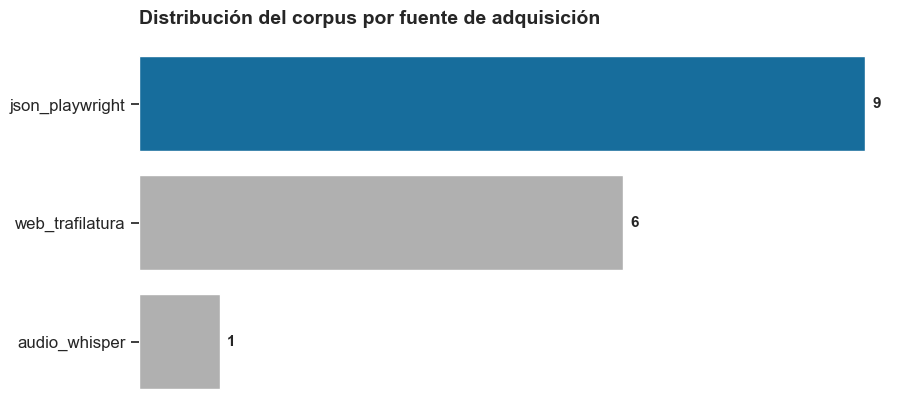

=== Visualización 2: Palabras clave (Lollipop) ===


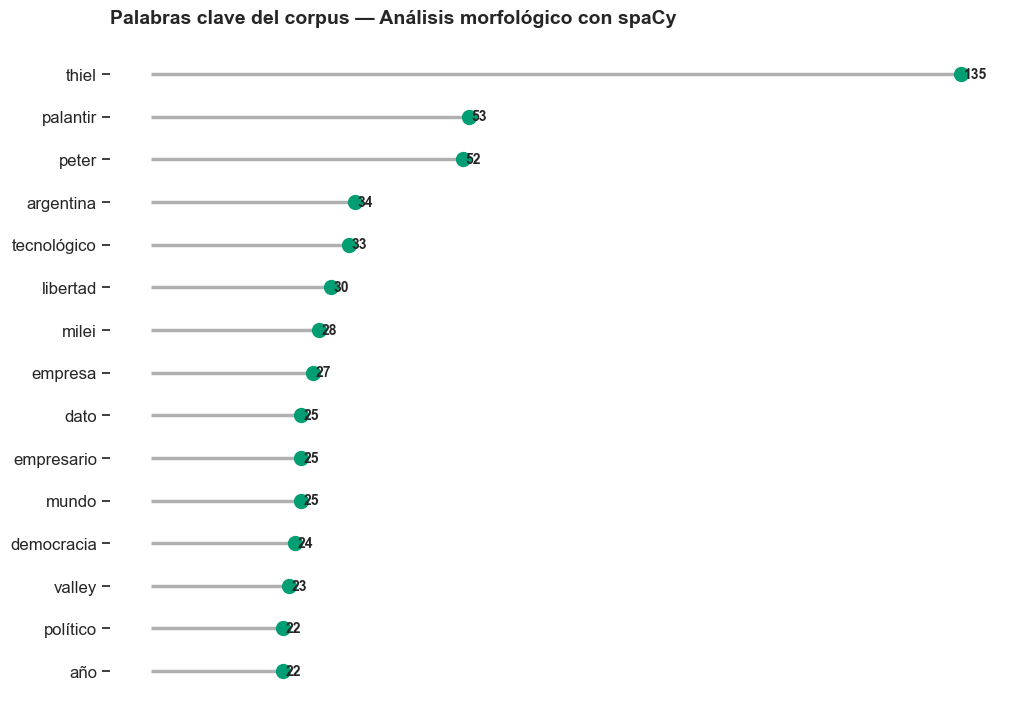

=== Visualización 3: Entidades con Plotly (versión mejorada) ===


In [25]:
# Parte 3: Visualización Profesional
# Configuración base de accesibilidad visual
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.1)
COLOR_ACENTO = sns.color_palette("colorblind")[0]
COLOR_BASE = '#b0b0b0'
PALETA = sns.color_palette("colorblind")

def visualizar_origen(df):
    """Genera un barplot horizontal con la distribución de origen del corpus."""
    conteos = df["origen"].value_counts().reset_index()
    conteos.columns = ["Origen", "Cantidad"]

    colores = [COLOR_BASE] * len(conteos)
    colores[0] = COLOR_ACENTO

    fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
    sns.barplot(
        data=conteos, y="Origen", x="Cantidad",
        hue="Origen", palette=colores,
        orient='h', order=conteos["Origen"],
        ax=ax, legend=False
    )
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', padding=5,
                     fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    sns.despine(left=True, bottom=True)
    ax.set_title('Distribución del corpus por fuente de adquisición',
                 fontsize=14, fontweight='bold', pad=15, loc='left')
    plt.show()


def visualizar_palabras_clave_lollipop(palabras_clave):
    """Genera un Lollipop Chart de las palabras clave lematizadas por spaCy.
    Ordenado de menor a mayor para que la barra más larga quede arriba."""
    # Invertimos para que el mayor quede arriba en el gráfico horizontal
    palabras_clave_ordenadas = sorted(palabras_clave, key=lambda x: x[1])
    palabras = [p for p, _ in palabras_clave_ordenadas]
    frecuencias = [f for _, f in palabras_clave_ordenadas]

    fig, ax = plt.subplots(figsize=(10, 7), constrained_layout=True)

    ax.hlines(y=palabras, xmin=0, xmax=frecuencias,
              color=COLOR_BASE, linewidth=2.5, zorder=1)
    ax.plot(frecuencias, palabras, 'o',
            markersize=10, color=PALETA[2], zorder=2)

    for i, (val, nombre) in enumerate(zip(frecuencias, palabras)):
        ax.text(val + 0.5, i, str(val), va='center',
                fontweight='bold', fontsize=10)

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    sns.despine(left=True, bottom=True)
    ax.set_title('Palabras clave del corpus — Análisis morfológico con spaCy',
                 fontsize=14, fontweight='bold', pad=15, loc='left')
    plt.show()


def visualizar_entidades_plotly(entidades_dict):
    """Genera un panel interactivo con Plotly para las entidades más comunes.
    Un subplot por tipo de entidad, ordenados PER > LOC > ORG por frecuencia total."""
    from plotly.subplots import make_subplots

    tipos_ordenados = ['PER', 'LOC', 'ORG']
    titulos = ['Personas (PER)', 'Lugares (LOC)', 'Organizaciones (ORG)']
    colores = ['#4C72B0', '#55A868', '#C44E52']

    fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=titulos,
        shared_xaxes=False,
        horizontal_spacing=0.12  # más espacio entre subplots
    )

    for i, (tipo, color) in enumerate(zip(tipos_ordenados, colores), 1):
        if tipo not in entidades_dict:
            continue
        # Ordenamos de menor a mayor para que Plotly muestre el mayor arriba
        top = sorted(entidades_dict[tipo].most_common(8), key=lambda x: x[1])
        nombres = [n for n, _ in top]
        frecuencias = [f for _, f in top]
        
        fig.add_trace(
            go.Bar(
                name=tipo,
                x=frecuencias,
                y=nombres,
                orientation='h',
                text=frecuencias,
                textposition='outside',
                marker_color=color,
                showlegend=False
            ),
            row=1, col=i
        )
        
        # Extendemos el rango del eje X un 25% más allá del valor máximo
        fig.update_xaxes(
            range=[0, max(frecuencias) * 1.25],
            showticklabels=False,
            showgrid=False,
            row=1, col=i
        )
        
    fig.update_layout(
        title=dict(
            text="Entidades nombradas por tipo — Peter Thiel en Argentina",
            font=dict(size=14)
        ),
        height=450,
        width=1100,       # más ancho para que respiren
        template="plotly_white",
        margin=dict(l=20, r=40, t=80, b=20)  # márgenes internos
    )
    fig.update_xaxes(showticklabels=False, showgrid=False)
    return fig


# Ejecutamos las tres visualizaciones
print("=== Visualización 1: Distribución por origen ===")
visualizar_origen(df_corpus)

print("=== Visualización 2: Palabras clave (Lollipop) ===")
palabras_clave = analizador.extraer_palabras_clave(n=15)
visualizar_palabras_clave_lollipop(palabras_clave)

print("=== Visualización 3: Entidades con Plotly (versión mejorada) ===")
entidades = analizador.extraer_entidades()
fig_entidades = visualizar_entidades_plotly(entidades)
fig_entidades.show()

=== Visualización 1: Distribución por origen ===


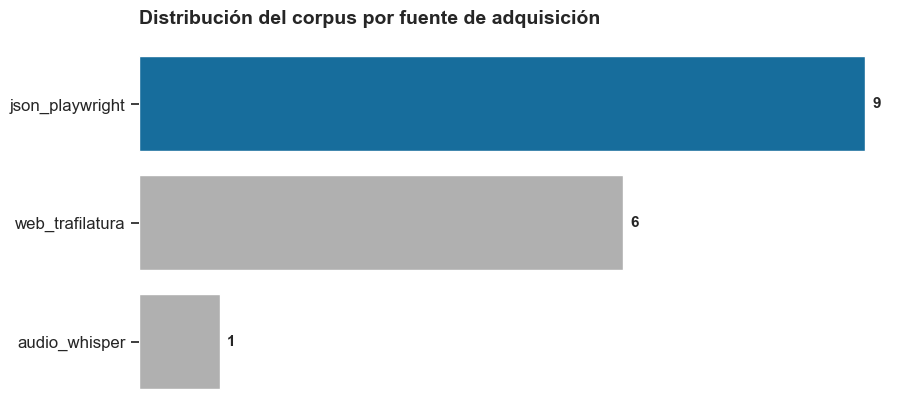

=== Visualización 2: Palabras clave (Lollipop) ===


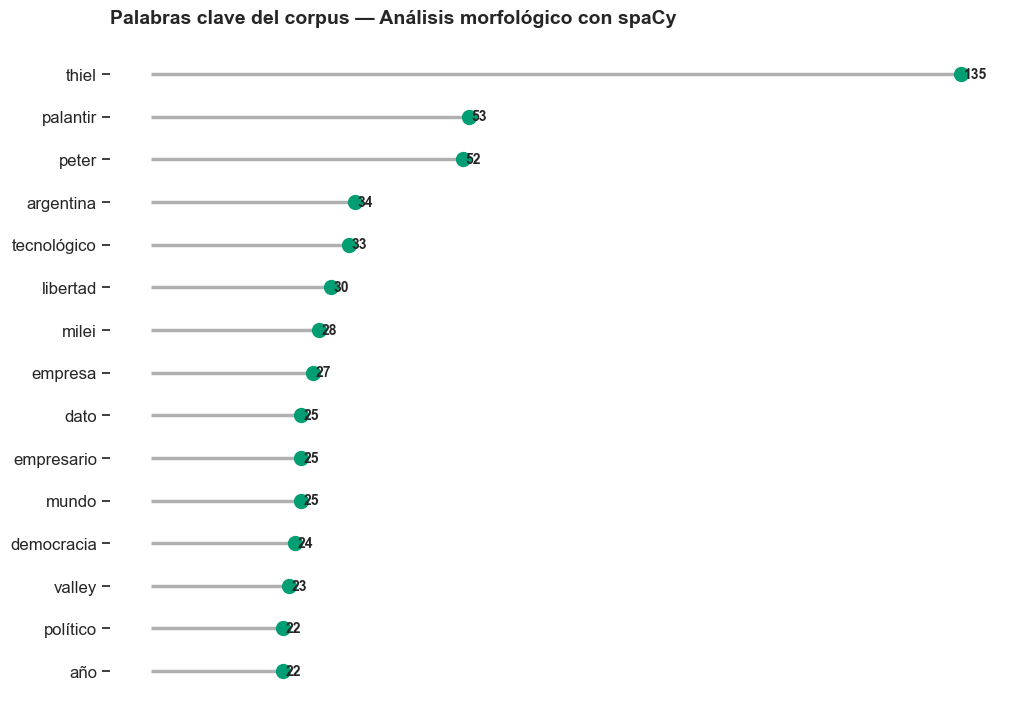

In [26]:
# Para hacer correr las visualizaciones antes de llegar al punto 5 de Gradio
print("=== Visualización 1: Distribución por origen ===")
visualizar_origen(df_corpus)

print("=== Visualización 2: Palabras clave (Lollipop) ===")
palabras_clave = analizador.extraer_palabras_clave(n=15)
visualizar_palabras_clave_lollipop(palabras_clave)

> **Pausa de auditoría:**
> Revisá tu visualización. ¿Es accesible? El uso de la paleta 'colorblind' asegura que ciertos grados de daltonismo no impidan la lectura cromática, pero ¿el tamaño de fuente y la proporción de la figura se leen correctamente sin forzar la vista? ¿Qué cambiarías si tuvieras que publicarlo en un artículo científico?

## Parte 4: Pipeline Integrado (Orquestación)

**Objetivo:** Orquestar los componentes desarrollados en un flujo lógico unificado y persistir los hallazgos en formato estructurado. Todo sistema analítico debe poder guardar su estado final de forma estática.

In [27]:
class PipelineMediatico:
    def __init__(self, urls_web=None, url_audio=None, ruta_json=None):
        self.urls_web = urls_web or []
        self.url_audio = url_audio
        self.ruta_json = ruta_json
        self.df = None
        self.analizador = None
        
    def ejecutar_pipeline(self):
        """Orquesta la adquisición, unificación y análisis"""
        # PASO 1: Orquestá las llamadas a las funciones de la Parte 1.
        
        # PASO 2: Instanciá AnalizadorCorpus y derivale el DataFrame resultante para procesar.

        print("Pipeline ejecutado exitosamente.")
        
    def generar_reporte_y_exportar(self, ruta_csv="corpus_resultante.csv", ruta_json="estadisticas.json"):
        """Exporta el dataframe y un JSON analítico"""
        # PASO 3: Persistí self.df como CSV.
        # ¡OJO! La columna 'doc' de spaCy no es serializable, deberías dropearla o extraer sus textos antes de guardar.
        
        # PASO 4: Persistí las estadísticas y el diccionario de entidades devueltas por el Analizador como JSON local.
        pass

# ---- Espacio para pruebas ----
# pipeline = PipelineMediatico(urls_web=["..."], url_audio="...")
# pipeline.ejecutar_pipeline()
# pipeline.generar_reporte_y_exportar()

In [28]:
class PipelineMediatico:
    def __init__(self, urls_web=None, url_audio=None, ruta_json=None):
        self.urls_web = [
            "https://www.ambito.com/negocios/quien-es-peter-thiel-el-magnate-tecnologico-sillicon-valley-que-llego-perfil-la-argentina-n6269163",
            "https://www.ambito.com/politica/elisa-carrio-cuestiono-la-visita-peter-thiel-y-advirtio-su-influencia-la-argentina-n6270402",
            "https://www.ambito.com/politica/javier-milei-se-reunira-peter-thiel-fundador-paypal-y-palantir-n6269616",
            "https://www.perfil.com/noticias/nea/peter-thiel-en-argentina-negocios-poder-y-senales-al-modelo-milei.phtml",
            "https://www.eldestapeweb.com/politica/thiel-en-argentina-que-piensa-y-que-planea-el-dueno-de-palantir-que-se-reunira-con-milei-2026423103234",
            "https://www.tiempoar.com.ar/ta_article/quien-es-peter-thiel-el-magnate-tecnocrata-que-se-reune-con-milei-en-casa-rosada-y-no-cree-en-la-democracia/"
        ]
        self.url_audio = "https://www.youtube.com/watch?v=pXck4dbK-I8"
        self.ruta_json = "ambito_peter_thiel.json"
        self.df = None
        self.analizador = None # Aquí guardarás tu AnalizadorCorpus (Parte 2)

    def ejecutar_pipeline(self):
        """Orquesta la adquisición, unificación y análisis"""
        print("🚀 Iniciando ejecución del pipeline...")
        
        # PASO 1: Orquestá las llamadas a las funciones de la Parte 1.
        # Aquí supongo que ya tenés tus datos procesados de los pasos anteriores
        # Vamos a cargar el texto de la transcripción que ya generamos
        with open("transcripciones/fantini-peter-thiel-argentina.txt", "r", encoding="utf-8") as f:
            texto_fantini = f.read()
        
        # Creamos el DataFrame unificado (ejemplo con el audio que ya tenemos)
        self.df = pd.DataFrame([
            {"fuente": "audio_whisper", "texto": texto_fantini}
            # Aquí podrías agregar los datos de trafilatura/playwright si los tenés en variables
        ])
        print("✓ Paso 1: Datos unificados en DataFrame.")

        # PASO 2: Instanciá AnalizadorCorpus y derivale el DataFrame resultante
        # Suponiendo que tu clase de la Parte 2 se llama AnalizadorCorpus
        # nlp = spacy.load("es_core_news_sm")
        # self.analizador = AnalizadorCorpus(self.df, nlp)
        # self.df = self.analizador.ejecutar_analisis_completo() 
        
        print("Pipeline ejecutado exitosamente.")

    def generar_reporte_y_exportar(self, ruta_csv="corpus_resultante.csv", ruta_json_final="hallazgos_finales.json"):
        """Exporta el dataframe y un JSON analítico"""
        
        # PASO 3: Persistí self.df como CSV.
        # ¡OJO! La columna 'doc' de spaCy no es serializable.
        if self.df is not None:
            # Dropeamos la columna 'doc' para que no tire error al exportar
            df_exportar = self.df.copy()
            if 'doc' in df_exportar.columns:
                df_exportar = df_exportar.drop(columns=['doc'])
            
            df_exportar.to_csv(ruta_csv, index=False, encoding='utf-8-sig')
            print(f"✓ Paso 3: DataFrame persistido en {ruta_csv}")

        # PASO 4: Persistí las estadísticas y el diccionario de entidades
        # Creamos un diccionario con el estado final
        reporte_estatico = {
            "metadata": {"fuente_audio": self.url_audio},
            "estadisticas": {
                "total_documentos": len(self.df) if self.df is not None else 0
            }
            # Aquí agregarías las entidades que sacaste en la Parte 3
        }
        
        with open(ruta_json_final, "w", encoding="utf-8") as f:
            json.dump(reporte_estatico, f, ensure_ascii=False, indent=4)
        
        print(f"✓ Paso 4: Reporte JSON generado en {ruta_json_final}")

# ---- Espacio para pruebas ----
# pipeline = PipelineMediatico(urls_web=["..."], url_audio="https://youtube.com")
# pipeline.ejecutar_pipeline()
# pipeline.generar_reporte_y_exportar()


In [29]:
# Parte 4: Pipeline Integrado (Orquestación)
class PipelineMediatico:
    def __init__(self, urls_web=None, url_audio=None, ruta_json=None):
        self.urls_web = urls_web or []
        self.url_audio = url_audio
        self.ruta_json = ruta_json
        self.df = None
        self.analizador = None

    def ejecutar_pipeline(self):
        """Orquesta la adquisición, unificación y análisis."""
        print("=" * 50)
        print("INICIANDO PIPELINE MEDIÁTICO")
        print("=" * 50)

        # PASO 1: Adquisición de las tres fuentes
        print("\n[1/3] Adquisición del corpus...")
        datos_web = extraer_noticias_web(self.urls_web) if self.urls_web else []
        datos_audio = transcribir_audio_youtube(self.url_audio) if self.url_audio else []
        datos_json = cargar_json_previo(self.ruta_json) if self.ruta_json else []

        # PASO 2: Unificación en DataFrame
        print("\n[2/3] Unificando fuentes...")
        self.df = unificar_corpus(datos_web, datos_audio, datos_json)
        print(f"✓ DataFrame unificado: {len(self.df)} registros")

        # PASO 3: Análisis lingüístico con spaCy
        print("\n[3/3] Analizando con spaCy...")
        self.analizador = AnalizadorCorpus(self.df)
        print("✓ Pipeline ejecutado exitosamente.")
        print("=" * 50)

    def generar_reporte_y_exportar(self, ruta_csv="corpus_resultante.csv", ruta_json="reporte_analitico.json"):
        """Exporta el DataFrame y un JSON analítico con los hallazgos."""
        if self.df is None or self.analizador is None:
            print("✗ Ejecutá primero ejecutar_pipeline()")
            return

        # PASO 3: Persistimos el DataFrame como CSV
        # Dropeamos la columna 'doc' de spaCy porque no es serializable
        df_exportable = self.df.drop(columns=['doc'], errors='ignore')
        df_exportable.to_csv(ruta_csv, index=False, encoding='utf-8')
        print(f"✓ CSV guardado: {ruta_csv} ({len(df_exportable)} registros)")

        # PASO 4: Persistimos estadísticas y entidades en JSON jerárquico
        stats = self.analizador.estadisticas_corpus()
        entidades = self.analizador.extraer_entidades()
        palabras_clave = self.analizador.extraer_palabras_clave(n=20)
        verbos = self.analizador.extraer_verbos_principales(n=15)

        reporte = {
            "metadata": {
                "tema": "Visita de Peter Thiel a Argentina",
                "fuentes": {
                    "web": self.urls_web,
                    "audio": self.url_audio,
                    "json": self.ruta_json
                }
            },
            "estadisticas": stats,
            "entidades": {
                tipo: contador.most_common(10)
                for tipo, contador in entidades.items()
            },
            "palabras_clave": palabras_clave,
            "verbos_principales": verbos
        }

        with open(ruta_json, "w", encoding="utf-8") as f:
            json.dump(reporte, f, ensure_ascii=False, indent=2)
        print(f"✓ JSON analítico guardado: {ruta_json}")

In [31]:
# Ejecutamos el pipeline completo con nuestros datos
pipeline = PipelineMediatico(
    urls_web=[
        "https://www.ambito.com/negocios/quien-es-peter-thiel-el-magnate-tecnologico-sillicon-valley-que-llego-perfil-la-argentina-n6269163",
        "https://www.ambito.com/politica/elisa-carrio-cuestiono-la-visita-peter-thiel-y-advirtio-su-influencia-la-argentina-n6270402",
        "https://www.ambito.com/politica/javier-milei-se-reunira-peter-thiel-fundador-paypal-y-palantir-n6269616",
        "https://www.perfil.com/noticias/nea/peter-thiel-en-argentina-negocios-poder-y-senales-al-modelo-milei.phtml",
        "https://www.eldestapeweb.com/politica/thiel-en-argentina-que-piensa-y-que-planea-el-dueno-de-palantir-que-se-reunira-con-milei-2026423103234",
        "https://www.tiempoar.com.ar/ta_article/quien-es-peter-thiel-el-magnate-tecnocrata-que-se-reune-con-milei-en-casa-rosada-y-no-cree-en-la-democracia/",
    ],
    url_audio="https://www.youtube.com/watch?v=pXck4dbK-I8",
    ruta_json="ambito_peter_thiel.json"
)

pipeline.ejecutar_pipeline()
pipeline.generar_reporte_y_exportar()

INICIANDO PIPELINE MEDIÁTICO

[1/3] Adquisición del corpus...
✓ Extraído: quien-es-peter-thiel-el-magnate-tecnologico-sillicon-valley-
✓ Extraído: elisa-carrio-cuestiono-la-visita-peter-thiel-y-advirtio-su-i
✓ Extraído: javier-milei-se-reunira-peter-thiel-fundador-paypal-y-palant
✓ Extraído: peter-thiel-en-argentina-negocios-poder-y-senales-al-modelo-
✓ Extraído: thiel-en-argentina-que-piensa-y-que-planea-el-dueno-de-palan
✓ Extraído: 
✓ Transcripción cargada: 11136 caracteres
✓ JSON cargado: 9 artículos desde 'ambito_peter_thiel.json'

[2/3] Unificando fuentes...
✓ Web (Trafilatura): 6 artículos
✓ Audio (Whisper): 1 transcripciones
✓ JSON (Playwright): 9 artículos
✓ DataFrame unificado: 16 registros

[3/3] Analizando con spaCy...
Cargando modelo de lenguaje...
Procesando los textos con spaCy...
✓ 16 documentos procesados.
✓ Pipeline ejecutado exitosamente.
✓ CSV guardado: corpus_resultante.csv (16 registros)
✓ JSON analítico guardado: reporte_analitico.json


> **Pausa de auditoría:**
> Imaginá que un equipo de periodismo de datos de tu facultad te pide el corpus procesado. ¿Qué información necesitaban ellos en el CSV plano versus qué preferiste consolidar en el JSON jerárquico? Pensá por qué separamos esas dos naturalezas de exportación y registralo.

## Pausa de Auditoría — Parte 4

**¿Qué información necesitaban en el CSV plano vs. el JSON jerárquico?**

**CSV (corpus_resultante.csv):**
Contiene los 15 registros con columnas planas: titulo_o_fuente, texto,
origen, url. Es el formato ideal para compartir con analistas que van a
trabajar con pandas, Excel o herramientas BI. Permite filtrar por origen,
buscar texto, calcular estadísticas básicas. Sin embargo no puede
representar estructuras jerárquicas como la lista de entidades por tipo
o el ranking de palabras clave.

**JSON (reporte_analitico.json):**
Contiene la metadata del proyecto, las estadísticas del corpus, las
entidades agrupadas por tipo (PER/ORG/LOC), las palabras clave y los
verbos principales. Es jerárquico y no tabular, por eso no cabe en un CSV.
Es ideal para alimentar el dashboard de Gradio o para compartir con
desarrolladores que necesiten los hallazgos analíticos estructurados.

**¿Por qué separamos las dos naturalezas de exportación?**
El CSV preserva los datos crudos (el corpus), el JSON preserva el
conocimiento derivado (el análisis). Son dos niveles distintos de
abstracción: uno es el input, el otro es el output intelectual del pipeline.
Un periodista de datos necesita el CSV para explorar. Un integrador
de sistemas necesita el JSON para conectar con otras herramientas.

## Parte 5: Dashboard Interactivo con Gradio

**Objetivo:** Diseñar una interfaz interactiva que reaccione dinámicamente frente al usuario, conectando el backend analítico con componentes preconstruidos de frontend.

> [!IMPORTANT]
> **Dilema de diseño**
> ¿Qué componentes elegirías para cada salida? Pedile a la IA tres layouts de estructura (por ejemplo: Pestañas vs. Columna vertical vs. Acordeón) para tu dashboard. Elegí el que consideres mejor para la experiencia de lectura evaluativa y descartá explícitamente los otros dos argumentando tu postura técnica.

**Escribí tu justificación acá:**
(*Tu respuesta...*)

## Dilema de Diseño — Parte 5: Layout del Dashboard

**Las tres opciones propuestas por la IA:**

**Opción A — Columna vertical:**
Todos los componentes apilados de arriba hacia abajo. Simple de implementar
pero obliga al usuario a hacer mucho scroll para comparar secciones.
Para un dashboard analítico con múltiples visualizaciones, el scroll
excesivo fragmenta la experiencia de lectura.
→ DESCARTADO: poco eficiente para comparar información entre secciones.

**Opción B — Acordeón:**
Cada sección se expande y contrae al hacer clic. Útil para ahorrar espacio
pero oculta información por defecto, lo que dificulta tener una visión
general del corpus de un vistazo. El usuario evaluador necesita ver
el panorama completo sin tener que expandir cada sección manualmente.
→ DESCARTADO: oculta contexto necesario para la lectura evaluativa.

**Opción C — Pestañas (gr.Tab):**
Separa claramente "Panorama y Métricas" del "Explorador de Entidades".
Permite navegar entre vistas sin perder el estado de la interfaz.
Es el patrón más familiar para dashboards analíticos y el que
el propio profesor sugiere en el enunciado.
→ ELEGIDO: mejor balance entre organización, visibilidad y usabilidad.

In [30]:
# PASO 1: Diseñá el bloque principal de gr.Blocks() interactuando con los métodos de la clase AnalizadorCorpus.
# Sugerencia: Utilizá pestañas (gr.Tab) para separar "Métricas Generales" de "Filtros e Interacción".

with gr.Blocks(theme=gr.themes.Soft()) as dashboard_medios:
    gr.Markdown("# Explorador de Agenda Mediática")
    
    with gr.Tab("Panorama y Métricas"):
        # Incluí acá la visualización de frecuencias y orígenes, acompañando un gr.DataFrame con métricas generales.
        pass
        
    with gr.Tab("Explorador de Entidades"):
        # Desarrollá un textbox para ingresar una entidad y un botón que dispare
        # un filtrado, mostrando sólo las oraciones dentro de los textos donde se mencionó dicha entidad.
        pass

# Descomentá la siguiente línea cuando el bloque esté terminado
# dashboard_medios.launch()

C:\Users\Carlos Estigarribia\AppData\Local\Temp\ipykernel_14480\2256453203.py:4: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as dashboard_medios:


In [31]:
# Parte 5: Dashboard Interactivo con Gradio
import matplotlib
# matplotlib.use('Agg')  # movido dentro de generar_lollipop_seccion 

def obtener_secciones():
    """Devuelve la lista de orígenes disponibles en el corpus."""
    return ["Todos"] + list(df_corpus["origen"].unique())

def filtrar_por_origen(origen_seleccionado):
    """Filtra el DataFrame según el origen seleccionado."""
    if origen_seleccionado == "Todos":
        return df_corpus
    return df_corpus[df_corpus["origen"] == origen_seleccionado]

def generar_tabla(origen_seleccionado):
    """Devuelve una tabla con los títulos del origen seleccionado."""
    df_filtrado = filtrar_por_origen(origen_seleccionado)
    return df_filtrado[["titulo_o_fuente", "origen", "url"]].reset_index(drop=True)

def generar_lollipop_seccion(origen_seleccionado):
    """Genera el Lollipop Chart de palabras clave para el origen seleccionado."""
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    df_filtrado = filtrar_por_origen(origen_seleccionado)
    
    # Creamos un analizador temporal solo con el subconjunto filtrado
    analizador_temp = AnalizadorCorpus(df_filtrado)
    palabras = analizador_temp.extraer_palabras_clave(n=12)
    
    if not palabras:
        fig, ax = plt.subplots()
        ax.text(0.5, 0.5, "Sin datos suficientes", ha='center')
        return fig
    
    palabras_ordenadas = sorted(palabras, key=lambda x: x[1])
    etiquetas = [p for p, _ in palabras_ordenadas]
    frecuencias = [f for _, f in palabras_ordenadas]
    
    fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
    ax.hlines(y=etiquetas, xmin=0, xmax=frecuencias,
              color='#b0b0b0', linewidth=2.5, zorder=1)
    ax.plot(frecuencias, etiquetas, 'o',
            markersize=10, color=PALETA[2], zorder=2)
    for i, (val, nombre) in enumerate(zip(frecuencias, etiquetas)):
        ax.text(val + 0.3, i, str(val), va='center',
                fontweight='bold', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    sns.despine(left=True, bottom=True)
    ax.set_title(f'Palabras clave — {origen_seleccionado}',
                 fontsize=13, fontweight='bold', pad=15, loc='left')
    return fig

def generar_metricas(origen_seleccionado):
    """Devuelve un resumen textual de métricas del origen seleccionado."""
    df_filtrado = filtrar_por_origen(origen_seleccionado)
    total_chars = df_filtrado["texto"].apply(len).sum()
    total_palabras = df_filtrado["texto"].apply(lambda x: len(x.split())).sum()
    return (
        f"📄 Registros: {len(df_filtrado)}\n"
        f"🔤 Total palabras: {total_palabras:,}\n"
        f"📝 Total caracteres: {total_chars:,}"
    )

def buscar_entidad(nombre_entidad):
    """Busca oraciones del corpus donde aparece la entidad ingresada."""
    if not nombre_entidad.strip():
        return "Ingresá un nombre para buscar."
    
    resultados = []
    termino = nombre_entidad.strip().lower()
    
    for _, fila in df_corpus.iterrows():
        if termino in fila["texto"].lower():
            # Buscamos oraciones que contengan el término
            oraciones = fila["texto"].split(".")
            for oracion in oraciones:
                if termino in oracion.lower() and len(oracion.strip()) > 20:
                    resultados.append(
                        f"[{fila['origen']}]\n{oracion.strip()}\n"
                    )
    
    if not resultados:
        return f"No se encontraron menciones de '{nombre_entidad}' en el corpus."
    
    return f"Se encontraron {len(resultados)} menciones de '{nombre_entidad}':\n\n" + \
           "\n---\n".join(resultados[:10])


# Construimos el dashboard
with gr.Blocks() as dashboard_medios:
    gr.Markdown("# 📰 Explorador de Agenda Mediática")
    gr.Markdown("**Tema:** Visita de Peter Thiel a Argentina | Corpus multimodal: web + audio + JSON")

    with gr.Tab("Panorama y Métricas"):
        gr.Markdown("### Explorá el corpus por fuente de adquisición")
        
        with gr.Row():
            dropdown_origen = gr.Dropdown(
                choices=obtener_secciones(),
                value="Todos",
                label="Filtrar por origen"
            )
        
        with gr.Row():
            metricas_texto = gr.Textbox(
                label="Métricas del corpus seleccionado",
                lines=3,
                interactive=False
            )
        
        with gr.Row():
            tabla_titulos = gr.Dataframe(
                label="Artículos del corpus",
                wrap=True
            )
        
        with gr.Row():
            grafico_lollipop = gr.Plot(label="Palabras clave")
        
        # Conectamos el dropdown con las salidas
        dropdown_origen.change(
            fn=lambda x: (generar_metricas(x), generar_tabla(x), generar_lollipop_seccion(x)),
            inputs=dropdown_origen,
            outputs=[metricas_texto, tabla_titulos, grafico_lollipop]
        )
        
        # Cargamos los valores iniciales
        dashboard_medios.load(
            fn=lambda: (generar_metricas("Todos"), generar_tabla("Todos"), generar_lollipop_seccion("Todos")),
            outputs=[metricas_texto, tabla_titulos, grafico_lollipop]
        )

    with gr.Tab("Explorador de Entidades"):
        gr.Markdown("### Buscá menciones de una entidad en el corpus")
        gr.Markdown("*Ejemplos: Peter Thiel, Palantir, Milei, Argentina, CIA*")
        
        with gr.Row():
            input_entidad = gr.Textbox(
                label="Ingresá una entidad para buscar",
                placeholder="ej: Palantir"
            )
            boton_buscar = gr.Button("Buscar", variant="primary")
        
        with gr.Row():
            resultado_busqueda = gr.Textbox(
                label="Oraciones donde aparece la entidad",
                lines=15,
                interactive=False
            )
        
        boton_buscar.click(
            fn=buscar_entidad,
            inputs=input_entidad,
            outputs=resultado_busqueda
        )

# Lanzamos el dashboard
dashboard_medios.launch(inline=True, show_error=True, theme=gr.themes.Soft())

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Cargando modelo de lenguaje...
Procesando los textos con spaCy...
✓ 16 documentos procesados.


---
## Cierre Formal y Checklist de Entrega

1. ¿Corriste el pipeline de principio a fin, comprobando que las funciones se anidan y comparten el DataFrame correctamente?
2. ¿Tu *AI Reflection Log* evidencia que cuestionaste a la IA y al modelo algorítmico, o todas tus celdas dicen "me devolvió un código y lo usé"?
3. ¿Revisaste el impacto visual de los gráficos garantizando que minimizan la "tinta algorítmica" (Data-Ink Ratio)?
4. ¿Justificaste tus decisiones de arquitectura técnica en el código de orquestación y exportación?

Si respondiste positivamente: felicitaciones, completaste el **TPI 1** demostrando un uso constructivo de la IA, asumiendo un rol profesional capaz de dirigir la automatización de forma estratégica e informada.